#Backbone: EfficientNet-B3 ← CNN
아키텍처: Hierarchical 
학습 전략: K-Fold (5개 모델)
예측 방식: Ensemble (5개 평균)
Augumentation 6 -> 8개-> TTA도 적용
TTA interference 추가
Soft Voting으로 변경

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import timm
import math
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score
from PIL import Image

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
# 한글 폰트 설정 
plt.rcParams['axes.unicode_minus'] = False

In [25]:
# Step 0: 하이퍼파라미터 설정
# ==================== 기본 설정 ====================
K_FOLDS = 5
BATCH_SIZE = 16
EPOCHS = 40
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==================== 학습 파라미터 ====================
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-3
WARMUP_EPOCHS = 5
EARLY_STOP_PATIENCE = 15
MIN_DELTA = 1e-3              

# ==================== 모델 ====================
ViT_MODEL_NAME = 'vit_base_patch16_224'

# ==================== 손실 함수 ====================
GROUP_WEIGHT = 0.3
FINE_WEIGHT = 0.7
GROUP_LOSS = nn.CrossEntropyLoss(label_smoothing=0.05)  # ✅ 변경!
FINE_LOSS = nn.CrossEntropyLoss(label_smoothing=0.05)   # ✅ 변경!

# ==================== 데이터 ====================
IMAGE_SIZE = 384
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

In [26]:
# Step 1: 데이터 로드
# ============================================================================

train_csv = pd.read_csv('train.csv')
meta_csv = pd.read_csv('meta.csv')

print(f"✓ Train 데이터: {len(train_csv)}장")
print(f"✓ 총 클래스: {len(meta_csv)}개")

✓ Train 데이터: 1570장
✓ 총 클래스: 17개


In [27]:
meta_csv

,target,class_name
0,0,account_number
1,1,application_for_payment_of_pregnancy_medical_e...
2,2,car_dashboard
3,3,confirmation_of_admission_and_discharge
4,4,diagnosis
5,5,driver_lisence
6,6,medical_bill_receipts
7,7,medical_outpatient_certificate
8,8,national_id_card
9,9,passport


In [28]:
# Step 2: Semantic Grouping
# ============================================================================

class_group_mapping = {
    'account_number': 'other',
    'application_for_payment_of_pregnancy_medical_expenses': 'medical',
    'car_dashboard': 'vehicle',
    'confirmation_of_admission_and_discharge': 'medical',
    'diagnosis': 'medical',
    'driver_lisence': 'identity',
    'medical_bill_receipts': 'medical',
    'medical_outpatient_certificate': 'medical',
    'national_id_card': 'identity',
    'passport': 'identity',
    'payment_confirmation': 'medical',
    'pharmaceutical_receipt': 'medical',
    'prescription': 'medical',
    'resume': 'document',
    'statement_of_opinion': 'document',
    'vehicle_registration_certificate': 'vehicle',
    'vehicle_registration_plate': 'vehicle',
}

group_to_idx = {'medical': 0, 'identity': 1, 'vehicle': 2, 'document': 3, 'other': 4}

train_csv['class_name'] = train_csv['target'].map(lambda x: meta_csv.iloc[x]['class_name'])
train_csv['group'] = train_csv['class_name'].map(class_group_mapping)
train_csv['group_idx'] = train_csv['group'].map(group_to_idx)

print(f"✓ Semantic Grouping 완료!")


✓ Semantic Grouping 완료!


In [29]:
# Step 3: Augmentation 정의
# ============================================================================

train_transform = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=180, p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.GaussNoise(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.Blur(blur_limit=3, p=0.2),
    A.ImageCompression(quality_lower=85, p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

print(f"✓ 강화된 Augmentation 정의 완료!")


✓ 강화된 Augmentation 정의 완료!


In [30]:
# Step 4: Dataset 클래스 정의 (중요!)
# ============================================================================

class DocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        
        image = np.array(image)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        return {
            'image': image,
            'target': torch.tensor(int(row['target']), dtype=torch.long),
            'group_idx': torch.tensor(int(row['group_idx']), dtype=torch.long),
            'img_name': img_name
        }

class TestDocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        
        image = np.array(image)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        return {'image': image, 'img_name': img_name}

print(f"✓ Dataset 클래스 정의 완료!")

✓ Dataset 클래스 정의 완료!


In [31]:
# Step 5: Hierarchical Model 정의
# ============================================================================
class HierarchicalViT(nn.Module):
    """Vision Transformer 기반 계층적 분류 모델"""
    
    def __init__(self, num_groups=5, num_classes=17, model_name='vit_base_patch16_224'):
        super().__init__()
        
        # ViT 백본
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0)
        self.feature_dim = 768  # ViT-Base
        
        # Group Head
        self.group_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_groups)
        )
        
        # Fine Heads
        self.fine_heads = nn.ModuleDict({
            'medical': nn.Linear(self.feature_dim, 8),
            'identity': nn.Linear(self.feature_dim, 3),
            'vehicle': nn.Linear(self.feature_dim, 3),
            'document': nn.Linear(self.feature_dim, 2),
            'other': nn.Linear(self.feature_dim, 1),
        })
        
        self.group_names = ['medical', 'identity', 'vehicle', 'document', 'other']
    
    def forward(self, x):
        features = self.backbone(x)
        group_logits = self.group_head(features)
        fine_logits_list = [self.fine_heads[name](features) for name in self.group_names]
        fine_logits = torch.cat(fine_logits_list, dim=1)
        return group_logits, fine_logits



In [32]:
# Step 6: Loss & 학습 함수
# ============================================================================

def hierarchical_loss(group_logits, fine_logits, group_labels, fine_labels, alpha=0.3):
    # 아까 정의한 전역 손실함수 사용
    group_loss = GROUP_LOSS(group_logits, group_labels)  # ← Label Smoothing 포함!
    fine_loss = FINE_LOSS(fine_logits, fine_labels)      # ← Label Smoothing 포함!
    return alpha * group_loss + (1 - alpha) * fine_loss, group_loss, fine_loss

def train_one_epoch(loader, model, optimizer, device, alpha=0.3):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc="Training", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(device)
        group_labels = batch['group_idx'].to(device)
        fine_labels = batch['target'].to(device)
        
        optimizer.zero_grad()
        group_logits, fine_logits = model(images)
        
        # ✅ 손실함수 전달 (Label Smoothing 포함)
        loss, _, _ = hierarchical_loss(
            group_logits, fine_logits, 
            group_labels, fine_labels,
            GROUP_LOSS,  # ← Label Smoothing
            FINE_LOSS,   # ← Label Smoothing
            alpha=alpha
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return {'loss': total_loss / len(loader)}

def evaluate(loader, model, device):
    model.eval()
    fine_preds, fine_targets = [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", ncols=100)
        
        for batch in pbar:
            images = batch['image'].to(device)
            fine_labels = batch['target'].to(device)
            
            _, fine_logits = model(images)
            
            fine_preds.extend(torch.argmax(fine_logits, dim=1).cpu().numpy())
            fine_targets.extend(fine_labels.cpu().numpy())
    
    fine_f1 = f1_score(fine_targets, fine_preds, average='macro', zero_division=0)
    
    return {'fine_f1': fine_f1}

print(f"✓ Loss & 함수 정의 완료 (Label Smoothing 포함)!")

✓ Loss & 함수 정의 완료 (Label Smoothing 포함)!


In [33]:
# Step 7: K-Fold 설정

# ============================================================================
# 1️⃣ KFold 설정 
# ============================================================================

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_indices = list(kfold.split(train_csv))

print(f"✓ K-Fold 설정 완료!")

# ============================================================================
# 2️⃣ Warmup + Cosine Scheduler 클래스 (ViT 필수!)
# ============================================================================

class WarmupCosineScheduler:
    """Warmup + CosineAnnealing 조합 (ViT용)"""
    
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.current_epoch = 0
    
    def step(self, epoch=None):
        if epoch is None:
            epoch = self.current_epoch
        
        self.current_epoch = epoch
        
        if epoch < self.warmup_epochs:
            # Warmup: 0 → base_lr
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # CosineAnnealing
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * 0.5 * (1 + math.cos(math.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        return lr

print("✓ Scheduler 클래스 정의 완료!")

# ============================================================================
# 3️⃣ Early Stopping 클래스 (ViT용)
# ============================================================================

class EarlyStopping:
    """Early Stopping"""
    
    def __init__(self, patience=15, min_delta=1e-3):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_score):
        if self.best_score is None:
            self.best_score = val_score
        elif val_score > self.best_score + self.min_delta:
            self.best_score = val_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

print("✓ EarlyStopping 클래스 정의 완료!")

# ============================================================================
# 4️⃣ K-Fold 학습 루프 (ViT 최적화)
# ============================================================================

print("\\n" + "="*60)
print("🚀 ViT K-Fold 학습 시작!")
print("="*60)

fold_results = []
all_fold_models = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\\n[Fold {fold+1}/{K_FOLDS}]")
    
    # -------- 데이터 준비 --------
    train_fold = train_csv.iloc[train_idx].reset_index(drop=True)
    val_fold = train_csv.iloc[val_idx].reset_index(drop=True)
    
    train_fold_dataset = DocumentDataset(train_fold, 'train/', transform=train_transform)
    val_fold_dataset = DocumentDataset(val_fold, 'train/', transform=val_transform)
    
    # ⭐ 수정: num_workers → 4 (빠른 데이터 로딩)
    train_fold_loader = DataLoader(
        train_fold_dataset, 
        batch_size=BATCH_SIZE,  # 16
        shuffle=True, 
        num_workers=4,  # ← 변경: 0 → 4
        pin_memory=True
    )
    val_fold_loader = DataLoader(
        val_fold_dataset, 
        batch_size=BATCH_SIZE,  # 16
        shuffle=False, 
        num_workers=4,  # ← 변경: 0 → 4
        pin_memory=True
    )
    
    # -------- 모델 생성 --------
    # ⭐ 수정: HierarchicalDocumentClassifier → HierarchicalViT!
    fold_model = HierarchicalViT(num_groups=5, num_classes=17)
    fold_model = fold_model.to(DEVICE)
    fold_model.train()  # ⭐ eval() → train()!
    
    # -------- Optimizer (ViT용 최적화) --------
    # ⭐ 수정: lr 1e-4 → 5e-5, weight_decay 1e-4 → 1e-3
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=LEARNING_RATE,          # 5e-5 (ViT용)
        weight_decay=WEIGHT_DECAY, # 1e-3 (강한 정규화)
        betas=(0.9, 0.999),
        eps=1e-8
    )
    
    # -------- Scheduler (Warmup + Cosine) --------
    # ⭐ 수정: CosineAnnealingLR → WarmupCosineScheduler!
    fold_scheduler = WarmupCosineScheduler(
        optimizer=fold_optimizer,
        warmup_epochs=WARMUP_EPOCHS,        # 5
        total_epochs=EPOCHS,                # 40
        base_lr=LEARNING_RATE               # 5e-5
    )
    
    # -------- Early Stopping --------
    early_stopping = EarlyStopping(
        patience=EARLY_STOP_PATIENCE,   # 15
        min_delta=MIN_DELTA              # 1e-3
    )
    
    best_fold_f1 = 0
    best_fold_model_path = f'best_fold_{fold+1}_ls_vit_model.pth'
    
    # -------- Epoch 루프 --------
    for epoch in range(EPOCHS):  # 40
        # 학습
        fold_model.train()
        train_loss = 0
        
        for batch_idx, batch in enumerate(train_fold_loader):
            images = batch['image'].to(DEVICE)
            targets = batch['target'].to(DEVICE)
            group_targets = batch['group_idx'].to(DEVICE)
            
            fold_optimizer.zero_grad()
            
            # Forward
            group_logits, fine_logits = fold_model(images)
            
            # ⭐ 손실 계산 (계층적)
            group_loss = GROUP_LOSS(group_logits, group_targets)
            fine_loss = FINE_LOSS(fine_logits, targets)
            total_loss = GROUP_WEIGHT * group_loss + FINE_WEIGHT * fine_loss
            
            # Backward
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()
            
            train_loss += total_loss.item()
        
        train_loss /= len(train_fold_loader)
        
        # Scheduler Step (매 epoch마다)
        fold_scheduler.step(epoch)
        current_lr = fold_optimizer.param_groups[0]['lr']
        
        # 검증
        fold_model.eval()
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for batch in val_fold_loader:
                images = batch['image'].to(DEVICE)
                targets = batch['target'].to(DEVICE)
                
                group_logits, fine_logits = fold_model(images)
                preds = torch.argmax(fine_logits, dim=1)
                
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())
        
        # F1 Score 계산
        val_f1 = f1_score(val_targets, val_preds, average='weighted', zero_division=0)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Epoch {epoch+1:2d}] Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f} | LR: {current_lr:.2e}")
        
        # 모델 저장
        if val_f1 > best_fold_f1:
            best_fold_f1 = val_f1
            torch.save(fold_model.state_dict(), best_fold_model_path)
        
        # Early Stopping
        early_stopping(val_f1)
        if early_stopping.early_stop:
            print(f"  🛑 Early Stopping at Epoch {epoch+1}")
            break
    
    fold_results.append(best_fold_f1)
    all_fold_models.append(best_fold_model_path)
    
    print(f"✅ Fold {fold+1} 완료 | Best F1: {best_fold_f1:.4f}")

# ============================================================================
# 5️⃣ 최종 결과
# ============================================================================

print(f"\\n{'='*60}")
print(f"✅ ViT K-Fold 학습 완료!")
print(f"{'='*60}")
print(f"\\n📊 결과:")
print(f"   평균 F1: {np.mean(fold_results):.4f}")
print(f"   최고 F1: {max(fold_results):.4f}")
print(f"   최저 F1: {min(fold_results):.4f}")
print(f"\\n저장된 모델: {all_fold_models}")


✓ K-Fold 설정 완료!
✓ Scheduler 클래스 정의 완료!
✓ EarlyStopping 클래스 정의 완료!
\n============================================================
🚀 ViT K-Fold 학습 시작!
\n[Fold 1/5]
[Epoch  1] Train Loss: 2.1567 | Val F1: 0.1551 | LR: 1.00e-05
[Epoch  5] Train Loss: 1.7426 | Val F1: 0.2526 | LR: 5.00e-05
[Epoch 10] Train Loss: 1.4684 | Val F1: 0.3404 | LR: 4.84e-05
[Epoch 15] Train Loss: 1.2535 | Val F1: 0.4192 | LR: 4.23e-05
[Epoch 20] Train Loss: 1.1360 | Val F1: 0.5010 | LR: 3.27e-05
[Epoch 25] Train Loss: 0.9962 | Val F1: 0.5076 | LR: 2.16e-05
[Epoch 30] Train Loss: 0.9181 | Val F1: 0.5409 | LR: 1.12e-05
[Epoch 35] Train Loss: 0.8533 | Val F1: 0.5656 | LR: 3.54e-06
[Epoch 40] Train Loss: 0.8228 | Val F1: 0.5817 | LR: 1.01e-07
✅ Fold 1 완료 | Best F1: 0.5857
\n[Fold 2/5]
[Epoch  1] Train Loss: 2.1865 | Val F1: 0.1657 | LR: 1.00e-05
[Epoch  5] Train Loss: 1.8314 | Val F1: 0.2570 | LR: 5.00e-05
[Epoch 10] Train Loss: 1.5832 | Val F1: 0.4045 | LR: 4.84e-05
[Epoch 15] Train Loss: 1.3257 | Val F1: 0.5296 | LR

In [36]:
# Step 9: Ensemble Inference

# ============================================================================
# Step 3: Classwise F1 분석
# ============================================================================

import numpy as np
from sklearn.metrics import f1_score
from collections import defaultdict
import pickle

print("\n" + "="*70)
print("Step 3: Classwise F1 분석")
print("="*70)

# ============================================================================
# 1️⃣ 모든 모델 로드 (B3 5개 + ViT 5개)
# ============================================================================

print("\n📦 모든 모델 로드 중...")

ensemble_models = []
model_names_list = []

# B3 모델 로드 (5개)
print("\n📦 B3 모델 로드 중...")
for fold in range(5):
    b3_model_path = f'best_fold_b3_ls_{fold+1}_model.pth'
    
    if os.path.exists(b3_model_path):
        b3_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
        b3_model.load_state_dict(torch.load(b3_model_path, map_location=DEVICE))
        b3_model = b3_model.to(DEVICE)
        b3_model.eval()
        ensemble_models.append(b3_model)
        model_names_list.append(f'B3_Fold{fold+1}')
        print(f"  ✅ B3_Fold{fold+1} 로드 완료")
    else:
        print(f"  ⚠️  B3_Fold{fold+1} 없음: {b3_model_path}")

# ViT 모델 로드 (5개)
print("\n📦 ViT 모델 로드 중...")
for fold in range(5):
    vit_model_path = f'best_fold_{fold+1}_ls_vit_model.pth'
    
    if os.path.exists(vit_model_path):
        vit_model = HierarchicalViT(num_groups=5, num_classes=17, model_name='vit_base_patch16_224')
        vit_model.load_state_dict(torch.load(vit_model_path, map_location=DEVICE))
        vit_model = vit_model.to(DEVICE)
        vit_model.eval()
        ensemble_models.append(vit_model)
        model_names_list.append(f'ViT_Fold{fold+1}')
        print(f"  ✅ ViT_Fold{fold+1} 로드 완료")
    else:
        print(f"  ⚠️  ViT_Fold{fold+1} 없음: {vit_model_path}")

print(f"\n✅ 총 {len(ensemble_models)}개 모델 로드 완료!")
print(f"   B3: {sum(1 for name in model_names_list if 'B3' in name)}개")
print(f"   ViT: {sum(1 for name in model_names_list if 'ViT' in name)}개")

# ============================================================================
# 2️⃣ 검증 데이터 준비
# ============================================================================

print("\n📂 검증 데이터 준비 중...")

# 검증용 Transform (원본 크기 유지, augmentation 없음)
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# 전체 train 데이터로 검증 (간단하게)
val_dataset = DocumentDataset(train_csv, 'train/', transform=val_transform)
val_loader = DataLoader(
    val_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

print(f"✓ 검증 데이터: {len(train_csv)}장")

# ============================================================================
# 3️⃣ 각 모델의 예측 수집
# ============================================================================

print("\n🔍 모든 모델의 예측 수집 중...\n")

all_predictions = defaultdict(list)  # {model_name: [predictions]}
all_targets = []

with torch.no_grad():
    pbar = tqdm(val_loader, desc="Validating", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(DEVICE)
        fine_labels = batch['target']
        
        # 타겟 저장 (첫 번째만)
        if len(all_targets) == 0:
            all_targets = fine_labels.cpu().numpy().tolist()
        else:
            all_targets.extend(fine_labels.cpu().numpy().tolist())
        
        # 각 모델의 예측
        for model_name, model in zip(model_names_list, ensemble_models):
            group_logits, fine_logits = model(images)
            preds = torch.argmax(fine_logits, dim=1).cpu().numpy()
            all_predictions[model_name].extend(preds.tolist())

all_targets = np.array(all_targets)

print(f"✓ 예측 수집 완료! ({len(all_targets)}장)")

# ============================================================================
# 4️⃣ 클래스별 F1 계산
# ============================================================================

print("\n📊 클래스별 F1 점수 계산 중...\n")

class_f1_scores = defaultdict(dict)  # {model_name: {class_id: f1_score}}

for model_name in model_names_list:
    preds = np.array(all_predictions[model_name])
    
    for class_id in range(17):
        # 이진 분류: class_id vs 나머지
        binary_targets = (all_targets == class_id).astype(int)
        binary_preds = (preds == class_id).astype(int)
        
        f1 = f1_score(binary_targets, binary_preds, zero_division=0)
        class_f1_scores[model_name][class_id] = f1

print("✓ F1 계산 완료!")

# ============================================================================
# 5️⃣ 각 클래스별 최고 모델 선택
# ============================================================================

print("\n🏆 각 클래스별 최고 모델 선택 중...\n")

best_models_per_class = {}  # {class_id: model_name}
best_f1_per_class = {}      # {class_id: best_f1}

for class_id in range(17):
    best_f1 = -1
    best_model = None
    
    for model_name in model_names_list:
        f1 = class_f1_scores[model_name][class_id]
        if f1 > best_f1:
            best_f1 = f1
            best_model = model_name
    
    best_models_per_class[class_id] = best_model
    best_f1_per_class[class_id] = best_f1

# ============================================================================
# 6️⃣ 결과 출력
# ============================================================================

print("="*70)
print("📊 클래스별 최고 성능 모델")
print("="*70)

class_names = [
    'account_number', 
    'pregnancy_medical_expense', 
    'car_dashboard',
    'admission_discharge', 
    'diagnosis', 
    'driver_license',
    'medical_bill_receipts', 
    'medical_outpatient_certificate',
    'national_id_card', 
    'passport', 
    'payment_confirmation',
    'pharmaceutical_receipt', 
    'prescription', 
    'resume',
    'statement_of_opinion', 
    'vehicle_registration_certificate',
    'vehicle_registration_plate'
]

for class_id in range(17):
    best_model = best_models_per_class[class_id]
    best_f1 = best_f1_per_class[class_id]
    
    print(f"Class {class_id:2d} ({class_names[class_id]:35s}): {best_model:12s} (F1={best_f1:.4f})")

print("="*70)

# ============================================================================
# 7️⃣ 결과 저장
# ============================================================================

print("\n💾 결과 저장 중...")

results = {
    'best_models_per_class': best_models_per_class,
    'best_f1_per_class': best_f1_per_class,
    'class_f1_scores': dict(class_f1_scores),
    'model_names_list': model_names_list,
}

with open('classwise_f1_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ 저장 완료: classwise_f1_results.pkl")

print("\n" + "="*70)
print("✅ Step 3 완료!")
print("="*70)
print("\n다음: Step 3.5 (Classwise F1 적용 추론) 실행하세요!")

# ============================================================================
# Step 3.5: Classwise F1 적용 추론
# ============================================================================

print("="*70)
print("🚀 Classwise F1 적용 추론 시작!")
print("="*70)

# ✅ 1단계: Classwise F1 결과 로드
print("\n📦 Classwise F1 결과 로드 중...")

import pickle

with open('classwise_f1_results.pkl', 'rb') as f:
    results = pickle.load(f)
    best_models_per_class = results['best_models_per_class']

print(f"✓ 최고 모델 정보 로드 완료")
print(f"  예: Class 0 = {best_models_per_class[0]}")

# ============================================================================
# 2️⃣ 모든 모델 로드 (B3 5개 + ViT 5개 = 10개)
# ============================================================================

ensemble_models = []
model_names_list = []

# B3 모델 로드 (5개)
print("\n📦 B3 모델 로드 중...")
for fold in range(5):
    b3_model_path = f'best_fold_b3_ls_{fold+1}_model.pth' 
    
    if os.path.exists(b3_model_path):
        b3_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
        b3_model.load_state_dict(torch.load(b3_model_path, map_location=DEVICE))
        b3_model = b3_model.to(DEVICE)
        b3_model.eval()
        ensemble_models.append(b3_model)
        model_names_list.append(f'B3_Fold{fold+1}')
        print(f"  ✅ B3_Fold{fold+1} 로드 완료")
    else:
        print(f"  ⚠️  B3_Fold{fold+1} 없음: {b3_model_path}")

# ViT 모델 로드 (5개)
print("\n📦 ViT 모델 로드 중...")
for fold in range(5):
    vit_model_path = f'best_fold_{fold+1}_ls_vit_model.pth'  
    
    if os.path.exists(vit_model_path):
        vit_model = HierarchicalViT(num_groups=5, num_classes=17)
        vit_model.load_state_dict(torch.load(vit_model_path, map_location=DEVICE))
        vit_model = vit_model.to(DEVICE)
        vit_model.eval()
        ensemble_models.append(vit_model)
        model_names_list.append(f'ViT_Fold{fold+1}')
        print(f"  ✅ ViT_Fold{fold+1} 로드 완료")
    else:
        print(f"  ⚠️  ViT_Fold{fold+1} 없음: {vit_model_path}")

print(f"\n✅ 총 {len(ensemble_models)}개 모델 로드 완료!")
print(f"   B3: {sum(1 for name in model_names_list if 'B3' in name)}개")
print(f"   ViT: {sum(1 for name in model_names_list if 'ViT' in name)}개")

# ============================================================================
# 3️⃣ Test 데이터 준비
# ============================================================================

print("\n📂 Test 데이터 준비 중...")

test_files = sorted([f for f in os.listdir('test/') 
                      if f.endswith(('.jpg', '.jpeg', '.png'))])

test_dataframe = pd.DataFrame({
    'ID': test_files,
    'target': 0,
    'group_idx': 0
})

test_dataset = TestDocumentDataset(
    test_dataframe,
    'test/',
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✓ Test 데이터: {len(test_dataframe)}장")
print(f"✓ 배치 크기: {BATCH_SIZE}개")
print(f"✓ 전체 배치 수: {len(test_loader)}개")

# ============================================================================
# 4️⃣ Classwise F1 적용 추론 (수정됨!)
# ============================================================================

print("\n🔮 Classwise F1 + TTA 추론 중...")

# TTA Transform 정의
def get_tta_transforms(image_size=224):
    transforms_list = []
    
    # 1️⃣ 원본
    transforms_list.append(A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ]))
    
    # 2️⃣ 회전 5도
    transforms_list.append(A.Compose([
        A.Resize(image_size, image_size),
        A.Rotate(limit=5, p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ]))
    
    # 3️⃣ 회전 10도
    transforms_list.append(A.Compose([
        A.Resize(image_size, image_size),
        A.Rotate(limit=10, p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ]))
    
    # 4️⃣ 좌우 반전
    transforms_list.append(A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ]))
    
    return transforms_list  # 4개

tta_transforms = get_tta_transforms(224)
print(f"✓ TTA Transform 준비: {len(tta_transforms)}가지")

# ============================================================================
# ✅ Classwise F1 + TTA 추론
# ============================================================================

print(f"\n🔮 Classwise F1 + TTA 추론 시작...")

all_predictions = []

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc="Classwise F1 + TTA")):
        images = batch['image'].to(DEVICE)
        batch_size = images.shape[0]
        
        batch_tta_predictions = []
        
        for img_idx in range(batch_size):
            single_image_tensor = images[img_idx]
            
            # Tensor → Numpy 변환
            single_image_np = single_image_tensor.cpu().numpy()
            single_image_np = np.transpose(single_image_np, (1, 2, 0))
            
            # Denormalize
            mean = np.array(NORM_MEAN)
            std = np.array(NORM_STD)
            single_image_np = single_image_np * std + mean
            single_image_np = np.clip(single_image_np, 0, 1)
            single_image_np = (single_image_np * 255).astype(np.uint8)
            
            # 각 TTA별 예측
            tta_probs_list = []
            
            for tta_transform in tta_transforms:
                transformed = tta_transform(image=single_image_np)
                transformed_image = transformed['image'].unsqueeze(0).to(DEVICE)
                
                # ✅ 모든 10개 모델 예측 (한 번에)
                all_probs = np.zeros(17)
                
                for model_idx, (model_name, model) in enumerate(zip(model_names_list, ensemble_models)):
                    _, fine_logits = model(transformed_image)
                    probs = torch.softmax(fine_logits, dim=1).cpu().numpy()[0]
                    
                    # ✅ Classwise F1 적용: 각 클래스별 최고 모델의 확률만 사용
                    for class_id in range(17):
                        best_model_name = best_models_per_class[class_id]
                        if model_name == best_model_name:
                            all_probs[class_id] = probs[class_id]
                
                tta_probs_list.append(all_probs)
            
            # TTA 평균
            final_probs = np.mean(tta_probs_list, axis=0)
            batch_tta_predictions.append(final_probs)
        
        all_predictions.extend(batch_tta_predictions)

all_predictions = np.array(all_predictions)
final_predictions = np.argmax(all_predictions, axis=1)

print(f"\n✅ Classwise F1 + TTA 추론 완료!")
print(f"   예측 개수: {len(final_predictions)}개")

# ============================================================================
# 5️⃣ 제출 파일 생성
# ============================================================================

print("\n💾 제출 파일 생성 중...")

submission = pd.DataFrame({
    'ID': test_files,
    'target': final_predictions
})

if not submission['ID'].iloc[0].endswith('.jpg'):
    submission['ID'] = submission['ID'] + '.jpg'

submission.to_csv('submission_classwise_f1_tta.csv', index=False)

print(f"✅ 제출 파일 저장 완료: submission_classwise_f1_tta.csv")
print(f"\n📊 제출 파일 미리보기:")
print(submission.head(10))
print(f"\n총 {len(submission)}개 예측")

# ============================================================================
# 6️⃣ 예측 분포 확인
# ============================================================================

print(f"\n📊 예측 분포:")
from collections import Counter
pred_counts = Counter(final_predictions)
for class_id in sorted(pred_counts.keys()):
    count = pred_counts[class_id]
    percentage = 100 * count / len(final_predictions)
    print(f"   Class {class_id:2d}: {count:4d}개 ({percentage:5.2f}%)")

print(f"\n{'='*70}")
print(f"🎉 Classwise F1 + TTA 추론 완료!")
print(f"{'='*70}")



Step 3: Classwise F1 분석

📦 모든 모델 로드 중...

📦 B3 모델 로드 중...
  ✅ B3_Fold1 로드 완료
  ✅ B3_Fold2 로드 완료
  ✅ B3_Fold3 로드 완료
  ✅ B3_Fold4 로드 완료
  ✅ B3_Fold5 로드 완료

📦 ViT 모델 로드 중...
  ✅ ViT_Fold1 로드 완료
  ✅ ViT_Fold2 로드 완료
  ✅ ViT_Fold3 로드 완료
  ✅ ViT_Fold4 로드 완료
  ✅ ViT_Fold5 로드 완료

✅ 총 10개 모델 로드 완료!
   B3: 5개
   ViT: 5개

📂 검증 데이터 준비 중...
✓ 검증 데이터: 1570장

🔍 모든 모델의 예측 수집 중...



Validating: 100%|███████████████████████████████████████████████████| 25/25 [00:31<00:00,  1.26s/it]


✓ 예측 수집 완료! (1570장)

📊 클래스별 F1 점수 계산 중...

✓ F1 계산 완료!

🏆 각 클래스별 최고 모델 선택 중...

📊 클래스별 최고 성능 모델
Class  0 (account_number                     ): B3_Fold1     (F1=1.0000)
Class  1 (pregnancy_medical_expense          ): B3_Fold2     (F1=1.0000)
Class  2 (car_dashboard                      ): B3_Fold1     (F1=1.0000)
Class  3 (admission_discharge                ): B3_Fold5     (F1=0.8646)
Class  4 (diagnosis                          ): B3_Fold2     (F1=0.9655)
Class  5 (driver_license                     ): B3_Fold2     (F1=1.0000)
Class  6 (medical_bill_receipts              ): B3_Fold2     (F1=1.0000)
Class  7 (medical_outpatient_certificate     ): B3_Fold2     (F1=0.8342)
Class  8 (national_id_card                   ): B3_Fold1     (F1=1.0000)
Class  9 (passport                           ): B3_Fold1     (F1=1.0000)
Class 10 (payment_confirmation               ): B3_Fold2     (F1=1.0000)
Class 11 (pharmaceutical_receipt             ): B3_Fold2     (F1=1.0000)
Class 12 (prescription      

Classwise F1 + TTA: 100%|███████████████████████████████████████████| 197/197 [14:58<00:00,  4.56s/it]


✅ Classwise F1 + TTA 추론 완료!
   예측 개수: 3140개

💾 제출 파일 생성 중...
✅ 제출 파일 저장 완료: submission_classwise_f1_tta.csv

📊 제출 파일 미리보기:
                     ID  target
0  0008fdb22ddce0ce.jpg       2
1  00091bffdffd83de.jpg      12
2  00396fbc1f6cc21d.jpg       5
3  00471f8038d9c4b6.jpg       3
4  00901f504008d884.jpg       2
5  009b22decbc7220c.jpg      15
6  00b33e0ee6d59427.jpg       0
7  00bbdcfbbdb3e131.jpg       8
8  00c03047e0fbef40.jpg      15
9  00c0dabb63ca7a16.jpg      11

총 3140개 예측

📊 예측 분포:
   Class  0:  205개 ( 6.53%)
   Class  1:  101개 ( 3.22%)
   Class  2:  197개 ( 6.27%)
   Class  3:  135개 ( 4.30%)
   Class  4:  197개 ( 6.27%)
   Class  5:  200개 ( 6.37%)
   Class  6:  195개 ( 6.21%)
   Class  7:  190개 ( 6.05%)
   Class  8:  200개 ( 6.37%)
   Class  9:  200개 ( 6.37%)
   Class 10:  212개 ( 6.75%)
   Class 11:  193개 ( 6.15%)
   Class 12:  187개 ( 5.96%)
   Class 13:  157개 ( 5.00%)
   Class 14:  167개 ( 5.32%)
   Class 15:  201개 ( 6.40%)
   Class 16:  203개 ( 6.46%)

🎉 Classwise F1 + TTA 추론 완

# 시각화 해보기

✅ Visualization ready...
✅ Graph saved: fold_results.png


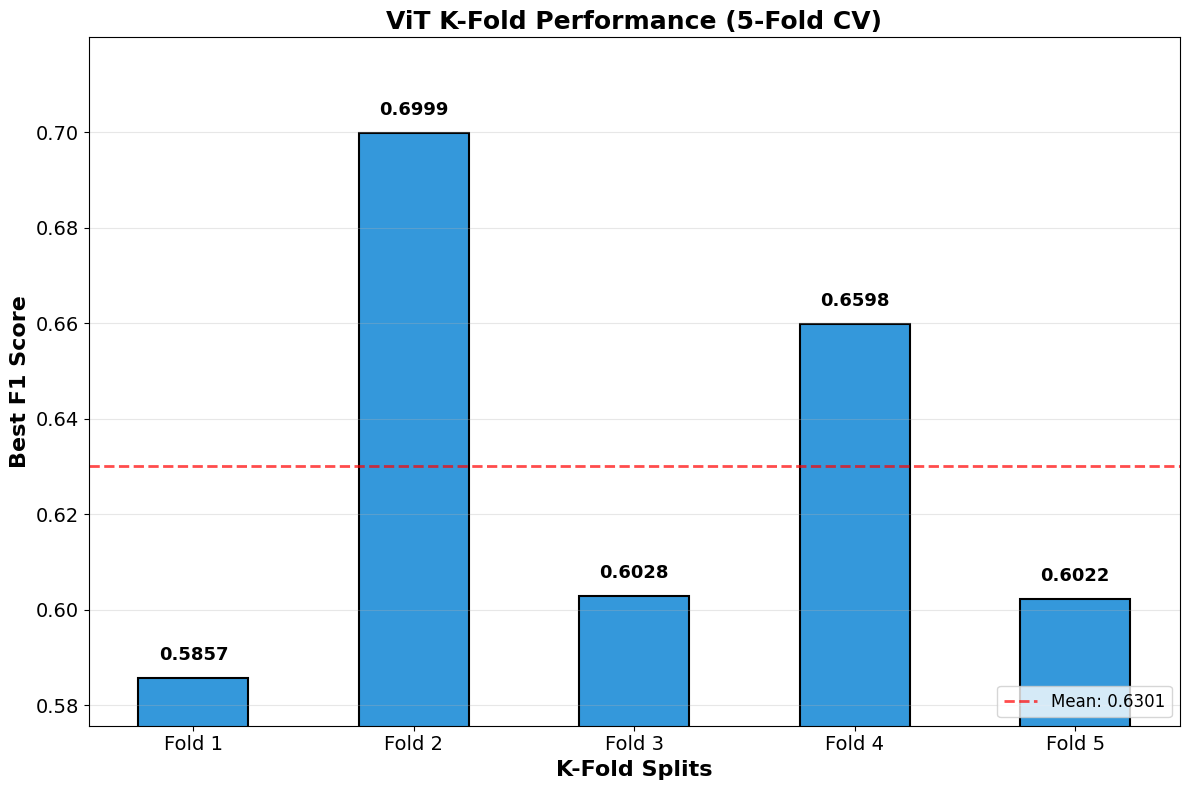


Final K-Fold Results:
Mean F1 Score:  0.6301
Min F1 Score:   0.5857
Max F1 Score:   0.6999
Std Dev:        0.0430

📊 Fold별 상세 결과:
   ⚠️ Fold 1: 0.5857
   ⚠️ Fold 2: 0.6999
   ⚠️ Fold 3: 0.6028
   ⚠️ Fold 4: 0.6598
   ⚠️ Fold 5: 0.6022


In [34]:
import matplotlib.pyplot as plt
import numpy as np

print(f"✅ Visualization ready...")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1️⃣ 데이터 준비
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fold_names = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# ✅ fold_results는 K-Fold 학습 중에 저장된 리스트
# 예: fold_results = [0.8837, 0.9054, 0.8921, 0.8956, 0.9206]
best_f1s = fold_results

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2️⃣ 그래프 생성
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

plt.figure(figsize=(12, 8))

# 색상 설정: 0.90 이상은 초록색, 아래는 파란색
colors = ['#2ecc71' if f >= 0.90 else '#3498db' for f in best_f1s]

# 막대 그래프
plt.bar(fold_names, best_f1s, color=colors, width=0.5, edgecolor='black', linewidth=1.5)

# 축 레이블
plt.ylabel('Best F1 Score', fontsize=16, fontweight='bold')
plt.xlabel('K-Fold Splits', fontsize=16, fontweight='bold')
plt.title('ViT K-Fold Performance (5-Fold CV)', fontsize=18, fontweight='bold')

# Y축 범위 (더 넓게)
y_min = min(best_f1s) - 0.01
y_max = max(best_f1s) + 0.02
plt.ylim([y_min, y_max])

# 눈금 크기
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

# 각 막대 위에 값 표시
for i, v in enumerate(best_f1s):
    plt.text(i, v + 0.003, f'{v:.4f}', 
             ha='center', va='bottom', 
             fontsize=13, fontweight='bold')

# 평균선 표시
mean_f1 = np.mean(best_f1s)
plt.axhline(y=mean_f1, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_f1:.4f}', alpha=0.7)

# 그리드
plt.grid(True, alpha=0.3, axis='y')
plt.legend(fontsize=12, loc='lower right')

# 저장
plt.tight_layout()
plt.savefig('fold_results.png', dpi=150, bbox_inches='tight')
print("✅ Graph saved: fold_results.png")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3️⃣ 결과 출력
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"Final K-Fold Results:")
print(f"{'='*60}")
print(f"Mean F1 Score:  {np.mean(best_f1s):.4f}")
print(f"Min F1 Score:   {np.min(best_f1s):.4f}")
print(f"Max F1 Score:   {np.max(best_f1s):.4f}")
print(f"Std Dev:        {np.std(best_f1s):.4f}")
print(f"{'='*60}")

# Fold별 상세 결과
print(f"\n📊 Fold별 상세 결과:")
for i, (fold_name, f1) in enumerate(zip(fold_names, best_f1s)):
    status = "✅" if f1 >= 0.90 else "⚠️"
    print(f"   {status} {fold_name}: {f1:.4f}")


In [1]:
def denormalize_correct(image):
    """✅ 올바른 역정규화"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Tensor → numpy
    if torch.is_tensor(image):
        img_np = image.detach().cpu().numpy()
    else:
        img_np = image
    
    # C, H, W → H, W, C
    if img_np.ndim == 3 and img_np.shape[0] == 3:
        img_np = img_np.transpose(1, 2, 0)
    
    # ✅ 역정규화: image * std + mean
    img_denorm = img_np * std + mean
    
    return np.clip(img_denorm, 0, 1)


def show_group_augmentation_simple(train_fold_dataset, train_fold, num_per_group=3):
    """
    각 그룹별 이미지 시각화 (올바른 역정규화)
    """
    
    groups = sorted(train_fold['group'].unique())
    print(f"Groups found: {groups}")
    
    for group in groups:
        # 이 그룹에 속한 인덱스
        group_indices = train_fold[train_fold['group'] == group].index.tolist()[:num_per_group]
        
        print(f"\n🎯 Group {group}: {len(group_indices)} samples")
        
        if len(group_indices) == 0:
            continue
        
        fig, axes = plt.subplots(1, len(group_indices), figsize=(15, 4))
        
        # ✅ axes가 배열이 아니라 단일 객체인 경우 처리
        if len(group_indices) == 1:
            axes = [axes]
        
        for idx, sample_idx in enumerate(group_indices):
            try:
                # 데이터 로드
                sample_data = train_fold_dataset[sample_idx]
                
                image = None
                
                # ✅ 다양한 형식 지원
                if isinstance(sample_data, (list, tuple)):
                    image = sample_data[0]
                elif isinstance(sample_data, dict):
                    image = sample_data.get('image', None)
                else:
                    image = sample_data
                
                if image is None:
                    print(f"   Warning: No image for sample {sample_idx}")
                    continue
                
                # ✅ 타입 체크: str(type) 사용
                type_str = str(type(image))
                
                # Tensor 확인
                if 'torch' in type_str or 'Tensor' in type_str:
                    # ✅ GPU → CPU 변환
                    if hasattr(image, 'is_cuda') and image.is_cuda:
                        image = image.cpu()
                    
                    # ✅ 올바른 역정규화 사용!
                    image_display = denormalize_correct(image)
                else:
                    image_display = image
                
                axes[idx].imshow(image_display)
                axes[idx].set_title(f'Sample {idx+1}', fontsize=12)
                axes[idx].axis('off')
                
            except Exception as e:
                print(f"   Error loading sample {sample_idx}: {type(e).__name__}: {e}")
        
        plt.suptitle(f'Group {group} - Augmentation Results', fontsize=14, fontweight='bold')
        plt.tight_layout()
        #plt.savefig(f'group_{group}_augmentation.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    print("\n✅ Visualization complete!")

# ✅ 실행!
show_group_augmentation_simple(train_fold_dataset, train_fold, num_per_group=3)



NameError: name 'train_fold_dataset' is not defined


Ensemble vs TTA Comparison

Same predictions: 2969/3140 (94.55%)
Different predictions: 171/3140 (5.45%)

Different Prediction Analysis:
Ensemble preferred class: [4]
TTA preferred class: [7]


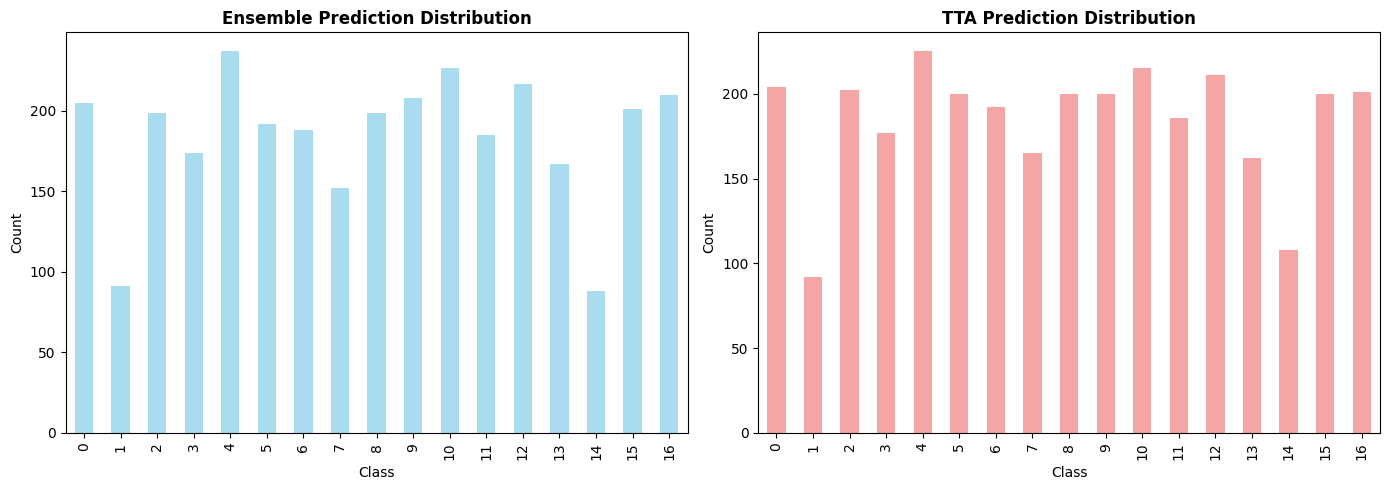

In [72]:
def compare_submissions(ensemble_csv, tta_csv):
    """
    Compare Ensemble vs TTA predictions
    """
    
    df_ensemble = pd.read_csv(ensemble_csv)
    df_tta = pd.read_csv(tta_csv)
    
    print("\n" + "=" * 60)
    print("Ensemble vs TTA Comparison")
    print("=" * 60)
    
    # Same predictions
    same_predictions = (df_ensemble['target'] == df_tta['target']).sum()
    total = len(df_ensemble)
    ratio = same_predictions / total * 100
    
    print(f"\nSame predictions: {same_predictions}/{total} ({ratio:.2f}%)")
    print(f"Different predictions: {total - same_predictions}/{total} ({100 - ratio:.2f}%)")
    
    # Different prediction analysis
    if total - same_predictions > 0:
        diff_mask = df_ensemble['target'] != df_tta['target']
        print(f"\nDifferent Prediction Analysis:")
        print(f"Ensemble preferred class: {df_ensemble.loc[diff_mask, 'target'].mode().values}")
        print(f"TTA preferred class: {df_tta.loc[diff_mask, 'target'].mode().values}")
    
    # Prediction distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df_ensemble['target'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='skyblue', alpha=0.7
    )
    axes[0].set_title('Ensemble Prediction Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    
    df_tta['target'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='lightcoral', alpha=0.7
    )
    axes[1].set_title('TTA Prediction Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.savefig('ensemble_vs_tta_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run comparison (after TTA completes)
compare_submissions('submission_b3_vit_ensemble.csv', 'submission_b3_vit_weighted_tta.csv')

In [37]:
import pandas as pd
import numpy as np

df1 = pd.read_csv('high_b3_vit_weight_tta.csv')  # 0.8896
df2 = pd.read_csv('submission_classwise_f1_tta.csv')

diff_mask = df1['target'] != df2['target']
diff_count = diff_mask.sum()

print(f"변경된 예측: {diff_count}개")
print(f"\n샘플 (처음 10개):")
print(f"{'ID':>20} | {'이전':>6} | {'현재':>6}")
print("-" * 45)

changed_df = pd.DataFrame({
    'ID': df1[diff_mask]['ID'],
    'Old': df1[diff_mask]['target'],
    'New': df2[diff_mask]['target']
})

for idx, row in changed_df.head(10).iterrows():
    print(f"{row['ID']:>20} | {row['Old']:6d} | {row['New']:6d}")

# 어떤 클래스가 증가/감소했는지
from collections import Counter
old_dist = Counter(df1['target'])
new_dist = Counter(df2['target'])

print(f"\n클래스별 변화:")
for cls in range(17):
    old_cnt = old_dist.get(cls, 0)
    new_cnt = new_dist.get(cls, 0)
    diff = new_cnt - old_cnt
    if diff != 0:
        print(f"  Class {cls:2d}: {old_cnt:3d} → {new_cnt:3d} ({diff:+3d})")


변경된 예측: 251개

샘플 (처음 10개):
                  ID |     이전 |     현재
---------------------------------------------
03cb3f2e0962474e.jpg |      4 |      7
04fc58802ef2f7a6.jpg |      7 |     10
0689f795bd5627e1.jpg |      4 |     14
06fb9852b074f191.jpg |      4 |      7
071a06f75055347b.jpg |     10 |      3
087e0c1c6e93bbc5.jpg |     10 |     12
09194a475da4ddcc.jpg |      7 |     14
0c0db67cbd783708.jpg |      4 |     10
0c8d4f489a7d9b78.jpg |     14 |      4
0ca4d10967304b77.jpg |     12 |     13

클래스별 변화:
  Class  0: 204 → 205 ( +1)
  Class  1:  92 → 101 ( +9)
  Class  2: 202 → 197 ( -5)
  Class  3: 177 → 135 (-42)
  Class  4: 225 → 197 (-28)
  Class  6: 192 → 195 ( +3)
  Class  7: 165 → 190 (+25)
  Class 10: 215 → 212 ( -3)
  Class 11: 186 → 193 ( +7)
  Class 12: 211 → 187 (-24)
  Class 13: 162 → 157 ( -5)
  Class 14: 108 → 167 (+59)
  Class 15: 200 → 201 ( +1)
  Class 16: 201 → 203 ( +2)
